<a href="https://colab.research.google.com/github/Chandu1722/ML/blob/main/Kaggle/DigitRecognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models,layers
import numpy as np
from sklearn.model_selection import train_test_split


In [24]:
train=pd.read_csv('train.csv')
train.shape

(42000, 785)

In [12]:
X=train.drop('label',axis=1)
Y=train['label']

In [13]:
X=X/255.0

In [14]:
X_reshape=X.values.reshape(-1,28,28,1)
y_cat=tf.keras.utils.to_categorical(Y,num_classes=10)

In [19]:
x_train,x_val,y_train,y_val=train_test_split(X_reshape,y_cat,test_size=0.2,random_state=42)

In [20]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_val,y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.8594 - loss: 0.4433 - val_accuracy: 0.9764 - val_loss: 0.0769
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.9801 - loss: 0.0634 - val_accuracy: 0.9770 - val_loss: 0.0729
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9873 - loss: 0.0446 - val_accuracy: 0.9854 - val_loss: 0.0451
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.9905 - loss: 0.0289 - val_accuracy: 0.9838 - val_loss: 0.0549
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.9918 - loss: 0.0250 - val_accuracy: 0.9869 - val_loss: 0.0469
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9868 - val_loss: 0.0451
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9865 - val_loss: 0.0420
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.9961 -

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9880 - loss: 0.0460

Validation Loss: 0.04668428748846054
Validation Accuracy: 98.82%


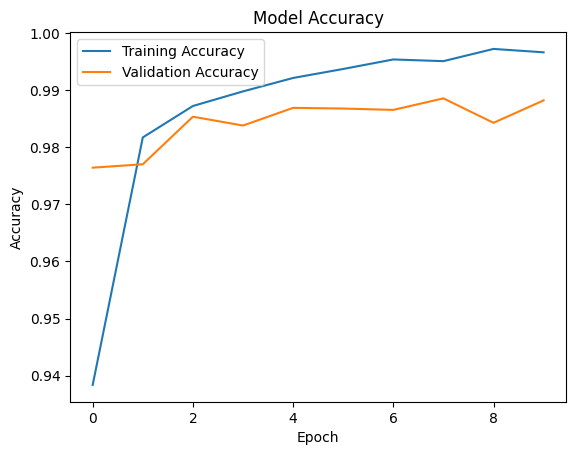

In [23]:
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(x_val, y_val)
print(f"\nValidation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# You can also plot the training history to see how it learned
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
test=pd.read_csv('test.csv')
test.shape

(28000, 784)

In [26]:
X=test/255.0

In [27]:
x_test_reshape=X.values.reshape(-1,28,28,1)

In [29]:
raw_pred=model.predict(x_test_reshape)

875/875 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [30]:
y_pred=np.argmax(raw_pred,axis=1)

In [31]:
output=pd.DataFrame({'ImageId':test.index+1,'Label':y_pred})
output.to_csv('submissionDigitRecognizer.csv',index=False)

In [32]:
from PIL import Image, ImageOps
img=Image.open('/content/my_digit.png')

In [39]:
img_g=img.convert('L')
img_re=img_g.resize((28,28),Image.LANCZOS)

In [40]:
img_invert=ImageOps.invert(img_re)
img_invert_arr=np.array(img_invert)
img_normal=img_invert_arr/255.0
img_final=img_normal.reshape(1,28,28,1)

In [41]:
pred=model.predict(img_final)
ans=np.argmax(pred)
print(ans)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
9
